# Feature extraction 

X_participant is the X matrix (one row per participant).

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path

# ----------------------------
# Config
# ----------------------------
IN_DIR = Path("../data/1_by_participant_standardized")   
OUT_PATH = Path("../data/X_pupil_participant.csv")

PUPIL_COL = "pupil_diameter_right_mm"   
TIME_COL  = "time_ms"
PART_COL  = "participant"

MIN_PUPIL_MM = 1.5
MAX_PUPIL_MM = 9.0

DO_INTERP = True
MAX_INTERP_GAP_MS = 200

# ----------------------------
# Helpers
# ----------------------------
def clean_pupil_series(df: pd.DataFrame) -> pd.DataFrame:
    """Return df with numeric time + cleaned pupil series (NaN for invalid; optional short-gap interpolation)."""
    out = df[[PART_COL, TIME_COL, PUPIL_COL]].copy()

    out[TIME_COL] = pd.to_numeric(out[TIME_COL], errors="coerce")
    out[PUPIL_COL] = pd.to_numeric(out[PUPIL_COL], errors="coerce")

    # invalid mask
    y = out[PUPIL_COL].to_numpy(dtype=float)
    invalid = (
        ~np.isfinite(y) |
        (y <= 0) |
        (y < MIN_PUPIL_MM) |
        (y > MAX_PUPIL_MM)
    )
    out["pupil_clean"] = out[PUPIL_COL].mask(invalid, np.nan)

    if not DO_INTERP:
        return out

    # interpolate short gaps ONLY (based on time_ms)
    t = out[TIME_COL].to_numpy(dtype=float)
    s = out["pupil_clean"]

    s_interp = s.interpolate(method="linear", limit_direction="both")

    isn = s.isna().to_numpy()
    if not isn.any():
        out["pupil_clean"] = s_interp
        return out

    # find NaN runs
    diff = np.diff(np.concatenate([[0], isn.view(np.int8), [0]]))
    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0] - 1

    s_out = s_interp.copy()
    for a, b in zip(starts, ends):
        if a < len(t) and b < len(t) and np.isfinite(t[a]) and np.isfinite(t[b]):
            gap_ms = t[b] - t[a]
        else:
            gap_ms = np.inf

        if gap_ms > MAX_INTERP_GAP_MS:
            s_out.iloc[a:b+1] = np.nan

    out["pupil_clean"] = s_out
    return out


def participant_features(df_clean: pd.DataFrame) -> dict:
    """Compute participant-level features from cleaned pupil + a centered version."""
    y_clean = df_clean["pupil_clean"].to_numpy(dtype=float)
    t = df_clean[TIME_COL].to_numpy(dtype=float)

    n_total = len(y_clean)
    n_valid = int(np.isfinite(y_clean).sum())
    missing_frac = 1.0 - (n_valid / n_total) if n_total else 1.0

    if n_valid == 0:
        return {
            "n_samples": n_total,
            "valid_samples": n_valid,
            "missing_frac": missing_frac,
            # raw-clean stats
            "pupil_mean": np.nan, "pupil_sd": np.nan, "pupil_range": np.nan, "pupil_iqr": np.nan,
            # centered stats
            "pupil_centered_mean": np.nan, "pupil_centered_sd": np.nan, "pupil_centered_range": np.nan, "pupil_centered_iqr": np.nan,
            # velocity stats (centered == same as clean for derivatives)
            "vel_mean_abs": np.nan, "vel_peak_abs": np.nan,
        }

    # ---- clean stats (absolute) ----
    pupil_mean = float(np.nanmean(y_clean))
    pupil_sd   = float(np.nanstd(y_clean))
    pupil_range = float(np.nanmax(y_clean) - np.nanmin(y_clean))
    q25, q75 = np.nanpercentile(y_clean, [25, 75])
    pupil_iqr = float(q75 - q25)

    # ---- centered signal ----
    med = float(np.nanmedian(y_clean))
    y_cent = y_clean - med

    centered_mean = float(np.nanmean(y_cent))
    centered_sd   = float(np.nanstd(y_cent))
    centered_range = float(np.nanmax(y_cent) - np.nanmin(y_cent))
    cq25, cq75 = np.nanpercentile(y_cent, [25, 75])
    centered_iqr = float(cq75 - cq25)

    # ---- velocity (mm/s) ----
    dt_s = np.diff(t) / 1000.0
    dy = np.diff(y_clean)  # derivative unaffected by subtracting a constant

    valid_v = np.isfinite(dt_s) & (dt_s > 0) & np.isfinite(dy)
    vel = np.full_like(dy, np.nan, dtype=float)
    vel[valid_v] = dy[valid_v] / dt_s[valid_v]

    vel_mean_abs = float(np.nanmean(np.abs(vel))) if np.isfinite(vel).any() else np.nan
    vel_peak_abs = float(np.nanmax(np.abs(vel))) if np.isfinite(vel).any() else np.nan

    return {
        "n_samples": n_total,
        "valid_samples": n_valid,
        "missing_frac": missing_frac,

        "pupil_mean": pupil_mean,
        "pupil_sd": pupil_sd,
        "pupil_range": pupil_range,
        "pupil_iqr": pupil_iqr,

        "pupil_centered_mean": centered_mean,
        "pupil_centered_sd": centered_sd,
        "pupil_centered_range": centered_range,
        "pupil_centered_iqr": centered_iqr,

        "vel_mean_abs": vel_mean_abs,
        "vel_peak_abs": vel_peak_abs,
    }

# ----------------------------
# Run (stream per file)
# ----------------------------
rows = []
for csv_path in sorted(IN_DIR.glob("participant_*.csv")):
    df = pd.read_csv(csv_path, low_memory=False)

    if PART_COL not in df.columns or TIME_COL not in df.columns or PUPIL_COL not in df.columns:
        print(f"Skipping {csv_path.name}: missing required columns")
        continue

    pid = pd.to_numeric(df[PART_COL].iloc[0], errors="coerce")
    df_clean = clean_pupil_series(df)

    feats = participant_features(df_clean)
    feats["participant"] = int(pid) if np.isfinite(pid) else csv_path.stem

    rows.append(feats)

X_participant = pd.DataFrame(rows).sort_values("participant").reset_index(drop=True)
X_participant.to_csv(OUT_PATH, index=False)

print("Saved:", OUT_PATH)
display(X_participant.head())
print("\nMissingness summary:")
print(X_participant["missing_frac"].describe())

Saved: ../data/X_pupil_participant.csv


,n_samples,valid_samples,missing_frac,pupil_mean,pupil_sd,pupil_range,pupil_iqr,pupil_centered_mean,pupil_centered_sd,pupil_centered_range,pupil_centered_iqr,vel_mean_abs,vel_peak_abs,participant
0,8531,8397,0.015707,4.362512,0.208468,2.7442,0.235176,-0.010088,0.208468,2.7442,0.235176,1.363033,139.646247,1
1,7132,3688,0.482894,4.342275,0.493758,4.9171,0.499850,0.016725,0.493758,4.9171,0.499850,3.122828,104.967787,2
2,8865,8865,0.000000,5.023573,0.243927,2.2214,0.356379,-0.015627,0.243927,2.2214,0.356379,1.284407,103.460838,3
3,9165,9097,0.007420,5.263662,0.637950,3.5913,1.413662,0.271062,0.637950,3.5913,1.413662,1.062410,121.906296,4
4,8449,4324,0.488223,3.228001,0.462325,4.4423,0.786550,0.004601,0.462325,4.4423,0.786550,2.729355,228.509934,5



Missingness summary:
count    57.000000
mean      0.166894
std       0.205404
min       0.000000
25%       0.004658
50%       0.035687
75%       0.360055
max       0.714445
Name: missing_frac, dtype: float64


- 	n_samples:
Total recorded samples for that participant.
-	valid_samples
Samples where pupil_right_mm was present and valid.
-	missing_frac:
Fraction of missing pupil data
→ this is a data quality + physiological behaviour feature.
-	pupil_mean:
Mean absolute pupil diameter (mm)
→ tonic arousal / baseline pupil size.
-	pupil_sd:
Variability of pupil size
→ autonomic instability / regulation differences.
-	pupil_range:
Max–min pupil size
→ overall dynamic span.
-	pupil_iqr:
Robust variability (less sensitive to outliers).
-  	vel_mean_abs:
Mean absolute pupil velocity
→ overall pupil reactivity.
-	vel_peak_abs:
Maximum pupil change rate
→ extreme responses / noise-sensitive.

In [4]:
import numpy as np
import pandas as pd
from pathlib import Path

IN_DIR = Path("../data/1_by_participant_standardized")
OUT_GAZE = Path("../data/X_gaze_participant.csv")

TIME_COL = "time_ms"
PART_COL = "participant"
CAT_COL  = "category_right"
X_COL    = "point_of_regard_right_x_px"
Y_COL    = "point_of_regard_right_y_px"

FIX_LABELS = {"fixation"}
SAC_LABELS = {"saccade"}

def _count_episodes(mask: np.ndarray) -> int:
    if mask.size == 0:
        return 0
    return int(np.sum((mask[1:].astype(int) - mask[:-1].astype(int)) == 1) + (1 if mask[0] else 0))

def gaze_features_one_participant(df: pd.DataFrame) -> dict:
    t = pd.to_numeric(df[TIME_COL], errors="coerce").to_numpy(dtype=float)
    cat = df[CAT_COL].astype(str).str.strip().str.lower().to_numpy()

    x = pd.to_numeric(df[X_COL].replace("-", np.nan), errors="coerce").to_numpy(dtype=float)
    y = pd.to_numeric(df[Y_COL].replace("-", np.nan), errors="coerce").to_numpy(dtype=float)

    # dt per sample (ms)
    dt = np.diff(t, prepend=t[0])
    dt[~np.isfinite(dt) | (dt < 0)] = 0.0

    is_fix = np.isin(cat, list(FIX_LABELS))
    is_sac = np.isin(cat, list(SAC_LABELS))

    fix_count = _count_episodes(is_fix)
    sac_count = _count_episodes(is_sac)

    mean_fix_dur_ms = float(dt[is_fix].sum() / fix_count) if fix_count > 0 else np.nan

    # saccade amplitude proxy (px per sample) during saccade-labeled samples
    dx = np.diff(x, prepend=x[0])
    dy = np.diff(y, prepend=y[0])
    amp = np.sqrt(dx*dx + dy*dy)
    amp[~np.isfinite(amp)] = np.nan

    mean_sac_amp = float(np.nanmean(amp[is_sac])) if np.any(is_sac) else np.nan

    return {
        "mean_fix_dur_ms": mean_fix_dur_ms,
        "fix_count": float(fix_count),
        "sac_count": float(sac_count),
        "mean_sac_amp": mean_sac_amp,
    }

rows = []
for csv_path in sorted(IN_DIR.glob("participant_*.csv")):
    df = pd.read_csv(csv_path, low_memory=False)

    required = {PART_COL, TIME_COL, CAT_COL, X_COL, Y_COL}
    if not required.issubset(df.columns):
        print(f"Skipping {csv_path.name}: missing {sorted(list(required - set(df.columns)))}")
        continue

    pid = int(pd.to_numeric(df[PART_COL].iloc[0], errors="coerce"))
    feats = gaze_features_one_participant(df)
    feats["participant"] = pid
    rows.append(feats)

X_gaze_participant = pd.DataFrame(rows).sort_values("participant").reset_index(drop=True)
X_gaze_participant.to_csv(OUT_GAZE, index=False)
print("Saved:", OUT_GAZE)
display(X_gaze_participant.head())

Saved: ../data/X_gaze_participant.csv


,mean_fix_dur_ms,fix_count,sac_count,mean_sac_amp,participant
0,329.283019,372.0,357.0,105.793329,1
1,342.519004,226.0,221.0,117.774752,2
2,401.998864,374.0,322.0,143.458274,3
3,307.683329,450.0,426.0,162.976293,4
4,311.328692,393.0,366.0,136.820578,5


In [8]:
from pathlib import Path
import pandas as pd
import numpy as np

# Paths (adjust if yours differ)
X_PUPIL = Path("../data/X_pupil_participant.csv")
X_GAZE  = Path("../data/X_gaze_participant.csv")
META    = Path("../data/_Metadata_Participants.csv")
OUT_DIR = Path("../data/features_participant")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Load
X_pupil = pd.read_csv(X_PUPIL)
X_gaze  = pd.read_csv(X_GAZE)
meta    = pd.read_csv(META)

# Labels
meta = meta.rename(columns={"ParticipantID": "participant", "Class": "label"})
meta["participant"] = pd.to_numeric(meta["participant"], errors="coerce").astype("int64")
meta["label"] = meta["label"].astype(str)

# Merge labels onto features
X_pupil_l = X_pupil.merge(meta[["participant","label"]], on="participant", how="inner")
X_gaze_l  = X_gaze.merge(meta[["participant","label"]], on="participant", how="inner")

# Combined: inner join on participants that have both
X_combined_l = (
    X_pupil.merge(X_gaze, on="participant", how="inner", suffixes=("_pupil", "_gaze"))
    .merge(meta[["participant","label"]], on="participant", how="inner")
)

# Define y and X matrices
y = X_pupil_l["label"].copy()

pupil_cols = [c for c in X_pupil_l.columns if c not in {"participant", "label"}]
gaze_cols  = [c for c in X_gaze_l.columns  if c not in {"participant", "label"}]
comb_cols  = [c for c in X_combined_l.columns if c not in {"participant", "label"}]

X_pupil_only = X_pupil_l[pupil_cols].copy()
X_gaze_only  = X_gaze_l[gaze_cols].copy()
X_combined   = X_combined_l[comb_cols].copy()
y_combined   = X_combined_l["label"].copy()

print("X_pupil_only:", X_pupil_only.shape, "y:", y.shape)
print("X_gaze_only :", X_gaze_only.shape,  "y:", X_gaze_l["label"].shape)
print("X_combined :", X_combined.shape,   "y:", y_combined.shape)

# Save
X_pupil_only.to_csv(OUT_DIR / "X_pupil_only.csv", index=False)
X_gaze_only.to_csv(OUT_DIR / "X_gaze_only.csv", index=False)
X_combined.to_csv(OUT_DIR / "X_combined.csv", index=False)
y.to_csv(OUT_DIR / "y.csv", index=False)
y_combined.to_csv(OUT_DIR / "y_combined.csv", index=False)

print("Saved matrices to:", OUT_DIR)

X_pupil_only: (57, 13) y: (57,)
X_gaze_only : (57, 4) y: (57,)
X_combined : (57, 17) y: (57,)
Saved matrices to: ../data/features_participant


Participant 10
Samples: 9289 | Missing samples: 4787 (51.53%)
Timeline duration: 242.9s | Gap time (approx): 143.9s (59.25%)
# gap intervals: 17


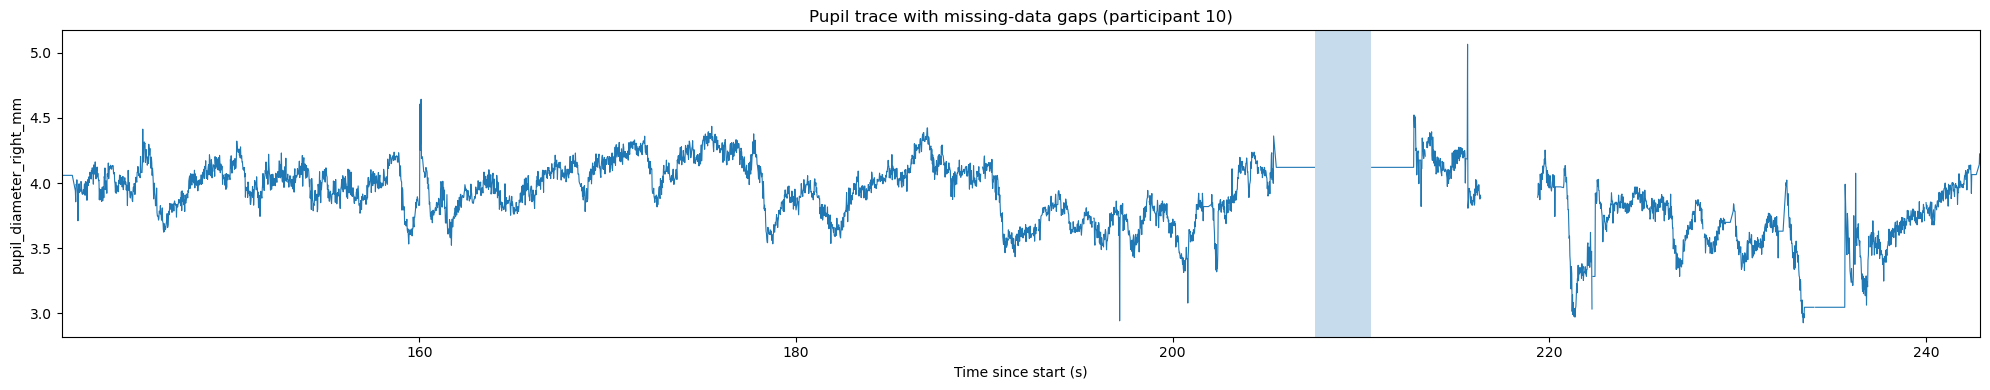

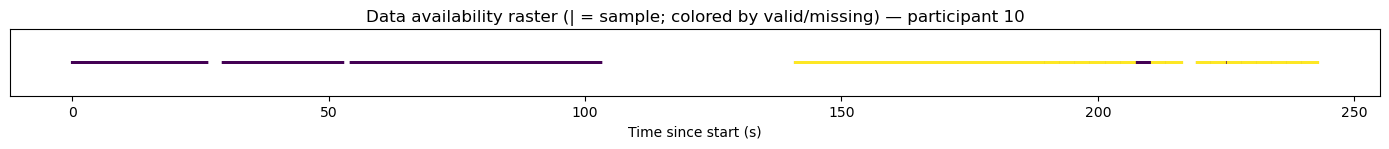

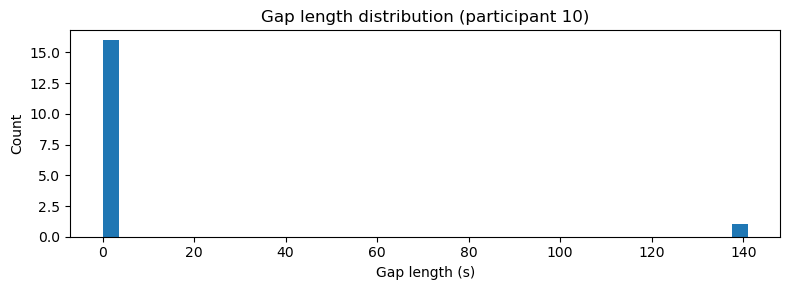

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# Config
# ----------------------------
IN_DIR = "../data/1_by_participant_standardized"   # folder with participant_*.csv
PARTICIPANT_ID = 10                                
TIME_COL = "time_ms"
PUPIL_COL = "pupil_diameter_right_mm"             # or "pupil_diameter_left_mm"

MIN_PUPIL_MM = 1.5
MAX_PUPIL_MM = 9.0

# ----------------------------
# Load one participant file
# ----------------------------
path = f"{IN_DIR}/participant_{PARTICIPANT_ID}.csv"
df = pd.read_csv(path, low_memory=False)

t = pd.to_numeric(df[TIME_COL], errors="coerce").to_numpy(dtype=float)
y = pd.to_numeric(df[PUPIL_COL], errors="coerce").to_numpy(dtype=float)

# invalid/missing definition (same as your cleaning rules)
missing = (
    ~np.isfinite(t) |
    ~np.isfinite(y) |
    (y <= 0) |
    (y < MIN_PUPIL_MM) |
    (y > MAX_PUPIL_MM)
)

# Sort by time (important if file ever gets unsorted)
order = np.argsort(t, kind="mergesort")
t = t[order]
y = y[order]
missing = missing[order]

# Convert to "time since start" in seconds for nicer axes
t0 = np.nanmin(t[np.isfinite(t)])
t_s = (t - t0) / 1000.0

# ----------------------------
# Find contiguous gap intervals
# ----------------------------
m = missing.astype(np.int8)
edges = np.diff(np.r_[0, m, 0])
starts = np.where(edges == 1)[0]
ends = np.where(edges == -1)[0] - 1

gap_intervals = []
for a, b in zip(starts, ends):
    if np.isfinite(t_s[a]) and np.isfinite(t_s[b]):
        gap_intervals.append((t_s[a], t_s[b]))

total_duration = np.nanmax(t_s[np.isfinite(t_s)]) - np.nanmin(t_s[np.isfinite(t_s)])
gap_duration = sum((b - a) for a, b in gap_intervals)
gap_frac_time = gap_duration / total_duration if total_duration > 0 else np.nan

print(f"Participant {PARTICIPANT_ID}")
print(f"Samples: {len(t_s)} | Missing samples: {missing.sum()} ({missing.mean():.2%})")
print(f"Timeline duration: {total_duration:.1f}s | Gap time (approx): {gap_duration:.1f}s ({gap_frac_time:.2%})")
print(f"# gap intervals: {len(gap_intervals)}")

# ----------------------------
# Plot 1: Pupil trace + shaded gaps
# ----------------------------
fig, ax = plt.subplots(figsize=(20, 4))
ax.plot(t_s, y, linewidth=0.8)
ax.set_title(f"Pupil trace with missing-data gaps (participant {PARTICIPANT_ID})")
ax.set_xlabel("Time since start (s)")
ax.set_ylabel(PUPIL_COL)

# shade gap intervals
for a, b in gap_intervals:
    ax.axvspan(a, b, alpha=0.25)

plt.xlim(
    np.nanmin(t_s[~missing]),
    np.nanmax(t_s[~missing])
)

plt.tight_layout()
plt.show()

# ----------------------------
# Plot 2: Gap raster (more compact)
# ----------------------------
fig, ax = plt.subplots(figsize=(14, 1.6))
ax.scatter(t_s, np.zeros_like(t_s), s=6, c=(~missing), marker="|")
ax.set_title(f"Data availability raster (| = sample; colored by valid/missing) — participant {PARTICIPANT_ID}")
ax.set_xlabel("Time since start (s)")
ax.set_yticks([])
plt.tight_layout()
plt.show()

# ----------------------------
# Optional: Plot 3 — Histogram of gap lengths
# ----------------------------
gap_lengths = np.array([b - a for a, b in gap_intervals], dtype=float)
if gap_lengths.size > 0:
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.hist(gap_lengths, bins=40)
    ax.set_title(f"Gap length distribution (participant {PARTICIPANT_ID})")
    ax.set_xlabel("Gap length (s)")
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()
else:
    print("No gaps found under the current missingness definition.")

“Visual inspection of pupil traces revealed long contiguous periods of missing data and a lack of clear trial-locked structure, motivating a shift from trial-level to participant-level feature aggregation.”This figure belongs in:
	•	Data quality / preprocessing section
	•	Or Appendix (QC figures)

In [12]:
print("Recording start (s):", np.nanmin(t_s))
print("Recording end (s):", np.nanmax(t_s))
print("First valid sample (s):", np.nanmin(t_s[~missing]))
print("Last valid sample (s):", np.nanmax(t_s[~missing]))

Recording start (s): 0.0
Recording end (s): 242.873077
First valid sample (s): 140.99717900000002
Last valid sample (s): 242.873077
